**How Much do Star Players Impact Winning in the NBA**

First we need to have a quantifiable measure of what a star is in order to classify our stars so lets quickly check that. We can do this analysis on the 2026 season as it has just concluded

In [35]:
import numpy as np
import seaborn as sns
from BRScraper import nba
import matplotlib.pyplot as plt
import pandas as pd

In [59]:
regstats26 = nba.get_stats(2026)
regstats26_sorted = regstats26.sort_values('Team', key=lambda x: x != '2TM')
regstats26_clean = regstats26_sorted.drop_duplicates(subset='Player', keep='first')
#regstats26_clean

In [60]:
advstats26 = nba.get_stats(2026, info='advanced')
advstats26_sorted = advstats26.sort_values('Team', key=lambda x: x != '2TM')
advstats26_clean = advstats26_sorted.drop_duplicates(subset='Player', keep='first')
#advstats26_clean

In [61]:
allstats26 = pd.merge(left=regstats26_clean, right=advstats26_clean, how='left', on='Player')
#allstats26

We now have all the stats aggregated into one big dataframe, the next thing will be to start querying for what we consider a *star* player

In [62]:
allstats26.columns

Index(['Player', 'Age_x', 'Team_x', 'Pos_x', 'G_x', 'GS_x', 'MP_x', 'FG',
       'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT',
       'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF',
       'PTS', 'Awards_x', 'Season_x', 'Age_y', 'Team_y', 'Pos_y', 'G_y',
       'GS_y', 'MP_y', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%',
       'AST%', 'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48',
       'OBPM', 'DBPM', 'BPM', 'VORP', 'Awards_y', 'Season_y'],
      dtype='object')

np.float64(27.1)

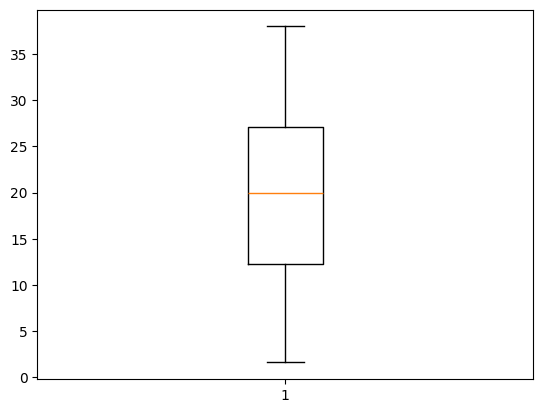

In [63]:
#lets look at a distribution of minutes played across the league, because a star player should be playing more than the average amount of minutes
plt.figure()
plt.boxplot(allstats26['MP_x'])
np.percentile(allstats26['MP_x'], 75)

In [64]:
#lets check how many players played above the average MP and above the upper quartile
uqMP = allstats26[allstats26['MP_x'] >=27.1]
print(f'The number of players who played above the upper quartile of MP was {uqMP.shape[0]}')
meanMP = allstats26[allstats26['MP_x'] >=np.mean(allstats26['MP_x'])]
print(f'The number of players who played above the mean of MP was {meanMP.shape[0]}')

The number of players who played above the upper quartile of MP was 147
The number of players who played above the mean of MP was 302


In [65]:
#302 is nearly half the league which is to be expected but 147 is still more than enough so lets use that as the
#baseline MP for determining a star

#query allstats for players playing above the min MP
uqMP.head()

,Player,Age_x,Team_x,Pos_x,G_x,GS_x,MP_x,FG,FGA,FG%,...,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Awards_y,Season_y
0,Ayo Dosunmu,26.0,2TM,SG,69.0,19.0,27.3,5.6,10.8,0.517,...,3.5,1.3,4.9,0.124,1.3,-0.3,1.0,1.4,6MOY-9,2025-26
3,Darius Garland,26.0,2TM,PG,45.0,43.0,29.9,6.9,14.9,0.460,...,1.7,0.9,2.6,0.092,2.2,-2.4,-0.2,0.6,NaN,2025-26
8,Jaren Jackson Jr.,26.0,2TM,C,48.0,48.0,30.3,7.1,15.0,0.476,...,0.1,1.3,1.4,0.047,-1.1,0.5,-0.6,0.5,NaN,2025-26
12,Ivica Zubac,28.0,2TM,C,48.0,47.0,30.1,6.0,10.0,0.598,...,2.6,1.6,4.2,0.139,0.7,-0.9,-0.3,0.6,NaN,2025-26
16,CJ McCollum,34.0,2TM,PG,76.0,60.0,29.8,6.9,15.2,0.455,...,1.9,1.0,3.0,0.063,1.4,-1.7,-0.3,1.0,NaN,2025-26


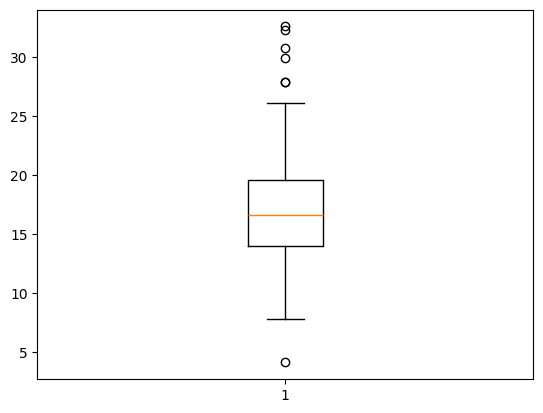

In [66]:
#now lets look at PER as this is a catchall stat and try to query the data down further
plt.figure
plt.boxplot(uqMP['PER'])
plt.show()

In [67]:
#lets check how many players are above the upperquartile for PER here
uqPER = uqMP[uqMP['PER'] >=np.percentile(uqMP['PER'],75)]
print(f'The number of players above the upper quartile of PER was {uqPER.shape[0]}')

The number of players above the upper quartile of PER was 37


In [68]:
#This is pretty close to the number of players that could reasonably be considered stars but lets look through this list
uqPER['Player']

48                James Harden
83                 Luka Dončić
309             Walker Kessler
327              Jarrett Allen
376              Austin Reaves
377              Jalen Johnson
379               Jayson Tatum
384            Zion Williamson
385               LeBron James
390              Anthony Davis
391             Alperen Şengün
395    Shai Gilgeous-Alexander
396            Anthony Edwards
397               Jaylen Brown
398               Tyrese Maxey
399              Kawhi Leonard
400           Donovan Mitchell
401               Nikola Jokić
402      Giannis Antetokounmpo
403            Cade Cunningham
404                Joel Embiid
405              Stephen Curry
406               Devin Booker
407              Jalen Brunson
408               Kevin Durant
409               Jamal Murray
410          Victor Wembanyama
411                Deni Avdija
412         Michael Porter Jr.
413            Lauri Markkanen
414            Donovan Clingan
416                LaMelo Ball
422     

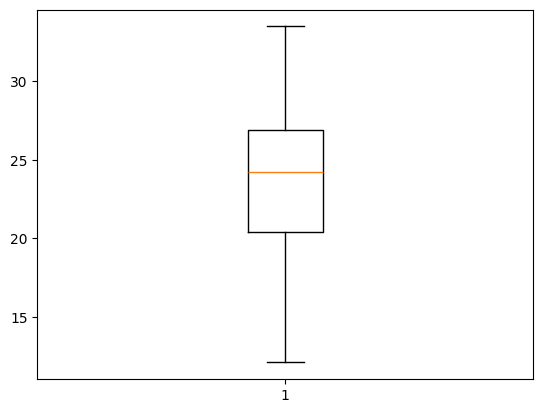

In [69]:
plt.figure()
plt.boxplot(uqPER['PTS'])
plt.show()

lets remove the players who average less than the lower quartile of points per game as they are strong players but don't quite have the offensive firepower to be considered a star

In [70]:
Stars = uqPER[uqPER['PTS'] >=np.percentile(uqPER['PTS'],25)]
Stars.loc[Stars['Player'] == 'James Harden', 'Team_x'] = 'CLE'
Stars.sort_values('PER', ascending = True)

,Player,Age_x,Team_x,Pos_x,G_x,GS_x,MP_x,FG,FGA,FG%,...,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Awards_y,Season_y
412,Michael Porter Jr.,27.0,BRK,SF,52.0,52.0,32.5,8.5,18.4,0.463,...,1.7,1.3,2.9,0.083,4.2,-1.2,3.0,2.1,NaN,2025-26
407,Jalen Brunson,29.0,NYK,PG,74.0,74.0,35.0,9.3,19.9,0.467,...,6.5,2.2,8.8,0.163,4.0,-0.9,3.1,3.3,"CPOY-5,AS",2025-26
376,Austin Reaves,27.0,LAL,SG,51.0,45.0,34.5,7.3,14.9,0.490,...,4.2,1.4,5.6,0.153,3.4,-0.6,2.8,2.1,NaN,2025-26
379,Jayson Tatum,27.0,BOS,PF,16.0,16.0,32.6,7.4,17.9,0.411,...,0.6,1.0,1.6,0.148,2.9,1.8,4.8,0.9,NaN,2025-26
411,Deni Avdija,25.0,POR,SF,66.0,66.0,33.3,7.5,16.1,0.462,...,4.5,2.4,7.0,0.152,3.7,0.6,4.3,3.5,AS,2025-26
406,Devin Booker,29.0,PHO,SG,64.0,64.0,33.5,8.5,18.7,0.456,...,4.7,1.8,6.5,0.145,3.2,-1.0,2.2,2.3,AS,2025-26
377,Jalen Johnson,24.0,ATL,SF,72.0,72.0,35.2,8.3,17.1,0.489,...,3.6,3.9,7.5,0.141,2.8,1.4,4.2,4.0,AS,2025-26
48,James Harden,36.0,CLE,PG,70.0,70.0,34.8,7.0,16.0,0.434,...,5.6,2.1,7.7,0.151,4.6,-0.8,3.9,3.6,NaN,2025-26
385,LeBron James,41.0,LAL,SF,60.0,60.0,33.2,7.9,15.3,0.515,...,3.4,2.1,5.4,0.131,3.3,0.2,3.5,2.8,AS,2025-26
408,Kevin Durant,37.0,HOU,SF,78.0,78.0,36.4,9.2,17.6,0.520,...,7.5,3.2,10.7,0.180,4.4,0.1,4.5,4.7,"CPOY-9,AS",2025-26


In [71]:
with pd.option_context('display.max_columns', None):
    print(Stars[Stars['Player'] == 'Michael Porter Jr.'])

                 Player  Age_x Team_x Pos_x   G_x  GS_x  MP_x   FG   FGA  \
412  Michael Porter Jr.   27.0    BRK    SF  52.0  52.0  32.5  8.5  18.4   

       FG%   3P  3PA    3P%   2P  2PA    2P%   eFG%   FT  FTA    FT%  ORB  \
412  0.463  3.4  9.3  0.363  5.2  9.1  0.567  0.555  3.8  4.4  0.859  1.3   

     DRB  TRB  AST  STL  BLK  TOV   PF   PTS Awards_x Season_x  Age_y Team_y  \
412  5.7  7.1  3.0  1.1  0.3  2.3  2.2  24.2      NaN  2025-26   27.0    BRK   

    Pos_y   G_y  GS_y    MP_y   PER    TS%   3PAr    FTr  ORB%  DRB%  TRB%  \
412    SF  52.0  52.0  1689.0  19.9  0.595  0.506  0.237   4.5  21.7  12.6   

     AST%  STL%  BLK%  TOV%  USG%  OWS  DWS   WS  WS/48  OBPM  DBPM  BPM  \
412  18.2   1.6   0.7  10.3  30.5  1.7  1.3  2.9  0.083   4.2  -1.2  3.0   

     VORP Awards_y Season_y  
412   2.1      NaN  2025-26  


So there we have it, our 28 data driven stars. This feels like a good number because I wanted it to be more than 24 (# of all stars) because using that would've been boring. Next lets group by team and count the number of stars on each team.

In [72]:
Starbyteam = Stars.groupby('Team_x').count().reset_index().rename(columns={'Team_x':'Team', 'Player':'Count'})[['Team', 'Count']]
#Line added because there was only 1 team with 3 stars so it didn't make sense to graph singular values later on
Starbyteam['Count_binned'] = pd.cut(Starbyteam['Count'], 
                            bins=[0, 1, 2, float('inf')], 
                            labels=[0, 1, '2+'], 
                            right=False)

Starbyteam

,Team,Count,Count_binned
0,ATL,1,1
1,BOS,2,2+
2,BRK,1,1
3,CLE,2,2+
4,DAL,1,1
5,DEN,2,2+
6,DET,1,1
7,GSW,1,1
8,HOU,2,2+
9,LAC,1,1


In [97]:
standings26 = pd.read_csv('./Data/NBAStandings26.csv')
standings26['Team']

0      Oklahoma City Thunder
1          San Antonio Spurs
2            Detroit Pistons
3             Boston Celtics
4             Denver Nuggets
5         Los Angeles Lakers
6            New York Knicks
7        Cleveland Cavaliers
8            Houston Rockets
9     Minnesota Timberwolves
10             Atlanta Hawks
11           Toronto Raptors
12             Orlando Magic
13        Philadelphia 76ers
14              Phoenix Suns
15         Charlotte Hornets
16                Miami Heat
17      Los Angeles Clippers
18    Portland Trail Blazers
19     Golden State Warriors
20           Milwaukee Bucks
21             Chicago Bulls
22          Dallas Mavericks
23      New Orleans Pelicans
24         Memphis Grizzlies
25          Sacramento Kings
26                 Utah Jazz
27             Brooklyn Nets
28            Indiana Pacers
29        Washington Wizards
Name: Team, dtype: object

In [98]:
abbreviations = [
    'OKC',   # Oklahoma City Thunder [citation:2][citation:7]
    'SAS',   # San Antonio Spurs [citation:7]
    'DET',   # Detroit Pistons [citation:2]
    'BOS',   # Boston Celtics [citation:2][citation:7]
    'DEN',   # Denver Nuggets [citation:2][citation:7]
    'LAL',   # Los Angeles Lakers [citation:2][citation:7]
    'NYK',   # New York Knicks [citation:2][citation:7]
    'CLE',   # Cleveland Cavaliers [citation:2][citation:7]
    'HOU',   # Houston Rockets [citation:2][citation:7]
    'MIN',   # Minnesota Timberwolves [citation:2][citation:7]
    'ATL',   # Atlanta Hawks [citation:2][citation:7]
    'TOR',   # Toronto Raptors [citation:2][citation:7]
    'ORL',   # Orlando Magic [citation:2][citation:7]
    'PHI',   # Philadelphia 76ers [citation:2][citation:7]
    'PHX',   # Phoenix Suns [citation:6][citation:7]
    'CHA',   # Charlotte Hornets [citation:7]
    'MIA',   # Miami Heat [citation:2][citation:7]
    'LAC',   # Los Angeles Clippers [citation:2][citation:7]
    'POR',   # Portland Trail Blazers [citation:2][citation:7]
    'GSW',   # Golden State Warriors [citation:2][citation:7]
    'MIL',   # Milwaukee Bucks [citation:2][citation:7]
    'CHI',   # Chicago Bulls [citation:2][citation:7]
    'DAL',   # Dallas Mavericks [citation:2][citation:7]
    'NOP',   # New Orleans Pelicans [citation:7] (also seen as 'NO')
    'MEM',   # Memphis Grizzlies [citation:2][citation:7]
    'SAC',   # Sacramento Kings [citation:2][citation:7]
    'UTA',   # Utah Jazz [citation:7]
    'BKN',   # Brooklyn Nets [citation:7]
    'IND',   # Indiana Pacers [citation:2][citation:7]
    'WAS'    # Washington Wizards [citation:2][citation:7]
]

# Add as a column to your DataFrame
standings26['Abbrev'] = abbreviations
standings26.head()

,Rk,Team,Overall,Home,Road,E,W,A,C,SE,...,≤3,≥10,Oct,Nov,Dec,Jan,Feb,Mar,Apr,Abbrev
0,1,Oklahoma City Thunder,64-18,34-8,30-10,23-7,41-11,8-2,7-3,8-2,...,5-6,43-9,6-0,14-1,9-4,9-6,8-4,14-1,4-2,OKC
1,2,San Antonio Spurs,62-20,32-8,30-12,26-4,36-16,9-1,8-2,9-1,...,8-5,43-8,5-0,8-6,11-3,8-7,11-0,14-2,5-2,SAS
2,3,Detroit Pistons,60-22,32-9,28-13,39-13,21-9,15-3,12-4,12-6,...,10-6,34-8,3-2,13-2,9-4,10-4,9-2,11-7,5-1,DET
3,4,Boston Celtics,56-26,30-11,26-15,36-16,20-10,10-6,12-6,14-4,...,5-7,38-10,3-3,8-6,9-3,10-6,9-2,11-5,6-1,BOS
4,5,Denver Nuggets,54-28,28-13,26-15,18-12,36-16,7-3,5-5,6-4,...,9-11,28-9,3-2,11-3,9-5,10-6,4-7,11-5,6-0,DEN


In [99]:
standings = pd.merge(standings26, Starbyteam, left_on='Abbrev', right_on='Team', how='left')
standings['Count_binned'] = standings['Count_binned'].fillna(0)  # Convert to int
standings.head()

,Rk,Team_x,Overall,Home,Road,E,W,A,C,SE,...,Nov,Dec,Jan,Feb,Mar,Apr,Abbrev,Team_y,Count,Count_binned
0,1,Oklahoma City Thunder,64-18,34-8,30-10,23-7,41-11,8-2,7-3,8-2,...,14-1,9-4,9-6,8-4,14-1,4-2,OKC,OKC,1.0,1
1,2,San Antonio Spurs,62-20,32-8,30-12,26-4,36-16,9-1,8-2,9-1,...,8-6,11-3,8-7,11-0,14-2,5-2,SAS,SAS,1.0,1
2,3,Detroit Pistons,60-22,32-9,28-13,39-13,21-9,15-3,12-4,12-6,...,13-2,9-4,10-4,9-2,11-7,5-1,DET,DET,1.0,1
3,4,Boston Celtics,56-26,30-11,26-15,36-16,20-10,10-6,12-6,14-4,...,8-6,9-3,10-6,9-2,11-5,6-1,BOS,BOS,2.0,2+
4,5,Denver Nuggets,54-28,28-13,26-15,18-12,36-16,7-3,5-5,6-4,...,11-3,9-5,10-6,4-7,11-5,6-0,DEN,DEN,2.0,2+


In [100]:
# Get current column list
cols = standings.columns.tolist()

# Remove 'Abbrev' from its current position
cols.remove('Abbrev')
cols.remove('Count_binned')

# Insert 'Abbrev' at position 1 (second column, since index 0 is first)
cols.insert(2, 'Abbrev')
cols.insert(4, 'Count_binned')
standings = standings[cols].rename(columns = {'Team_x':'Team', 'Count_binned':'NumStars'}).drop(columns='Team_y')
standings.head()

,Rk,Team,Abbrev,Overall,NumStars,Home,Road,E,W,A,...,≤3,≥10,Oct,Nov,Dec,Jan,Feb,Mar,Apr,Count
0,1,Oklahoma City Thunder,OKC,64-18,1,34-8,30-10,23-7,41-11,8-2,...,5-6,43-9,6-0,14-1,9-4,9-6,8-4,14-1,4-2,1.0
1,2,San Antonio Spurs,SAS,62-20,1,32-8,30-12,26-4,36-16,9-1,...,8-5,43-8,5-0,8-6,11-3,8-7,11-0,14-2,5-2,1.0
2,3,Detroit Pistons,DET,60-22,1,32-9,28-13,39-13,21-9,15-3,...,10-6,34-8,3-2,13-2,9-4,10-4,9-2,11-7,5-1,1.0
3,4,Boston Celtics,BOS,56-26,2+,30-11,26-15,36-16,20-10,10-6,...,5-7,38-10,3-3,8-6,9-3,10-6,9-2,11-5,6-1,2.0
4,5,Denver Nuggets,DEN,54-28,2+,28-13,26-15,18-12,36-16,7-3,...,9-11,28-9,3-2,11-3,9-5,10-6,4-7,11-5,6-0,2.0


In [101]:
#create win pct column by splitting string in overall column
standings['winpct'] = standings['Overall'].apply(lambda x: int(x.split('-')[0]) / (int(x.split('-')[0]) + int(x.split('-')[1])))
standings

,Rk,Team,Abbrev,Overall,NumStars,Home,Road,E,W,A,...,≥10,Oct,Nov,Dec,Jan,Feb,Mar,Apr,Count,winpct
0,1,Oklahoma City Thunder,OKC,64-18,1,34-8,30-10,23-7,41-11,8-2,...,43-9,6-0,14-1,9-4,9-6,8-4,14-1,4-2,1.0,0.780488
1,2,San Antonio Spurs,SAS,62-20,1,32-8,30-12,26-4,36-16,9-1,...,43-8,5-0,8-6,11-3,8-7,11-0,14-2,5-2,1.0,0.756098
2,3,Detroit Pistons,DET,60-22,1,32-9,28-13,39-13,21-9,15-3,...,34-8,3-2,13-2,9-4,10-4,9-2,11-7,5-1,1.0,0.731707
3,4,Boston Celtics,BOS,56-26,2+,30-11,26-15,36-16,20-10,10-6,...,38-10,3-3,8-6,9-3,10-6,9-2,11-5,6-1,2.0,0.682927
4,5,Denver Nuggets,DEN,54-28,2+,28-13,26-15,18-12,36-16,7-3,...,28-9,3-2,11-3,9-5,10-6,4-7,11-5,6-0,2.0,0.658537
5,6,Los Angeles Lakers,LAL,53-29,2+,28-13,25-16,20-10,33-19,7-3,...,28-21,4-2,11-2,5-7,9-7,6-6,15-2,3-3,3.0,0.646341
6,7,New York Knicks,NYK,53-29,1,30-10,23-19,35-17,18-12,14-3,...,32-19,2-3,11-3,10-4,7-8,8-4,10-6,5-1,1.0,0.646341
7,8,Cleveland Cavaliers,CLE,52-30,2+,27-14,25-16,33-19,19-11,8-8,...,27-17,3-3,9-6,7-7,10-5,8-3,10-5,5-1,2.0,0.634146
8,9,Houston Rockets,HOU,52-30,2+,30-11,22-19,23-7,29-23,7-3,...,27-11,2-2,11-2,7-6,10-7,7-5,9-7,6-1,2.0,0.634146
9,10,Minnesota Timberwolves,MIN,49-33,1,26-15,23-18,18-12,31-21,6-4,...,28-18,2-3,10-5,9-5,10-6,6-4,9-6,3-4,1.0,0.597561


In [102]:
starwinpct=standings.groupby('NumStars')[['winpct']].agg('mean').reset_index()
starwinpct

C:\Users\danie\AppData\Local\Temp\ipykernel_23532\3482230557.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  starwinpct=standings.groupby('NumStars')[['winpct']].agg('mean').reset_index()


,NumStars,winpct
0,0,0.395787
1,1,0.526266
2,2+,0.634146


In [103]:
from scipy import stats
# Create a numeric version of NumStars for statistical tests
standings['NumStars_numeric'] = standings['NumStars'].replace('2+', 2)

# Assuming your dataframe has 'winpct' and 'NumStars' columns
groups = [group['winpct'].values for name, group in standings.groupby('NumStars_numeric')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject null hypothesis - Significant difference in win% across star ratings")
else:
    print("Fail to reject null - No significant difference")

h_stat, p_value = stats.kruskal(*groups)
print(f"H-statistic: {h_stat}")
print(f"P-value: {p_value}")

F-statistic: 5.407526908247633
P-value: 0.010591002202737211
Reject null hypothesis - Significant difference in win% across star ratings
H-statistic: 9.507356690132612
P-value: 0.00861992974073711


C:\Users\danie\AppData\Local\Temp\ipykernel_23532\1416211998.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  standings['NumStars_numeric'] = standings['NumStars'].replace('2+', 2)
C:\Users\danie\AppData\Local\Temp\ipykernel_23532\1416211998.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  standings['NumStars_numeric'] = standings['NumStars'].replace('2+', 2)
C:\Users\danie\AppData\Local\Temp\ipykernel_23532\1416211998.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. 

In [104]:
#help(pd.DataFrame.agg)

In [105]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD test
tukey = pairwise_tukeyhsd(endog=standings['winpct'], 
                           groups=standings['NumStars_numeric'], 
                           alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   0.1305 0.0978 -0.0197 0.2807  False
     0      2   0.2384   0.01  0.0523 0.4244   True
     1      2   0.1079 0.3168  -0.073 0.2888  False
---------------------------------------------------


We can see that overall the difference in winpct by stars is in fact significant but when breaking down with a Turkey HSD test the only difference that is significant is between having 0 stars and having 2+ stars

In [106]:
from nba_api.stats.endpoints import leaguedashteamstats
from nba_api.stats.static import teams

# Set the season you want (e.g., "2023-24" for 2023-2024 season)
season = "2025-26"

# Fetch team advanced stats
team_stats = leaguedashteamstats.LeagueDashTeamStats(
    season=season,
    measure_type_detailed_defense="Advanced",  # Gets advanced metrics like ORtg, DRtg
    per_mode_detailed="PerGame",
    season_type_all_star="Regular Season"
)

# Convert to pandas DataFrame
nbaapistand = team_stats.get_data_frames()[0]

standings = standings.merge(nbaapistand, how='left', left_on='Team', right_on='TEAM_NAME')

In [107]:
standings = standings[['Team', 'NumStars', 'NumStars_numeric', 'Abbrev', 'Overall', 'winpct', 'OFF_RATING', 'DEF_RATING']]

In [108]:
clippers_off_rating = 117.3
clippers_def_rating = 116.1

# Find the Clippers row and update the values
standings.loc[standings['Team'] == 'Los Angeles Clippers', 'OFF_RATING'] = clippers_off_rating
standings.loc[standings['Team'] == 'Los Angeles Clippers', 'DEF_RATING'] = clippers_def_rating
standings

,Team,NumStars,NumStars_numeric,Abbrev,Overall,winpct,OFF_RATING,DEF_RATING
0,Oklahoma City Thunder,1,1,OKC,64-18,0.780488,117.6,106.5
1,San Antonio Spurs,1,1,SAS,62-20,0.756098,118.7,110.4
2,Detroit Pistons,1,1,DET,60-22,0.731707,117.3,108.9
3,Boston Celtics,2+,2,BOS,56-26,0.682927,120.0,111.7
4,Denver Nuggets,2+,2,DEN,54-28,0.658537,121.2,116.0
5,Los Angeles Lakers,2+,2,LAL,53-29,0.646341,117.0,115.5
6,New York Knicks,1,1,NYK,53-29,0.646341,118.7,112.3
7,Cleveland Cavaliers,2+,2,CLE,52-30,0.634146,118.3,114.1
8,Houston Rockets,2+,2,HOU,52-30,0.634146,117.5,112.1
9,Minnesota Timberwolves,1,1,MIN,49-33,0.597561,115.6,112.5


We now have a dataframe with the number of stars and the 3 variables that we want to examine in winpct (already statistically tested), offensive rating, and defensive rating

In [109]:
standings

,Team,NumStars,NumStars_numeric,Abbrev,Overall,winpct,OFF_RATING,DEF_RATING
0,Oklahoma City Thunder,1,1,OKC,64-18,0.780488,117.6,106.5
1,San Antonio Spurs,1,1,SAS,62-20,0.756098,118.7,110.4
2,Detroit Pistons,1,1,DET,60-22,0.731707,117.3,108.9
3,Boston Celtics,2+,2,BOS,56-26,0.682927,120.0,111.7
4,Denver Nuggets,2+,2,DEN,54-28,0.658537,121.2,116.0
5,Los Angeles Lakers,2+,2,LAL,53-29,0.646341,117.0,115.5
6,New York Knicks,1,1,NYK,53-29,0.646341,118.7,112.3
7,Cleveland Cavaliers,2+,2,CLE,52-30,0.634146,118.3,114.1
8,Houston Rockets,2+,2,HOU,52-30,0.634146,117.5,112.1
9,Minnesota Timberwolves,1,1,MIN,49-33,0.597561,115.6,112.5


**Lets examine offensive rating next**

In [111]:
# Assuming your dataframe has 'winpct' and 'NumStars' columns
Ogroups = [group['OFF_RATING'].values for name, group in standings.groupby('NumStars_numeric')]
f_stat, p_value = stats.f_oneway(*Ogroups)

print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject null hypothesis - Significant difference in OFFRating across star ratings")
else:
    print("Fail to reject null - No significant difference")

h_stat, p_value = stats.kruskal(*Ogroups)
print(f"H-statistic: {h_stat}")
print(f"P-value: {p_value}")


F-statistic: 6.973787638099189
P-value: 0.0036168479488376307
Reject null hypothesis - Significant difference in OFFRating across star ratings
H-statistic: 9.046158102270326
P-value: 0.010855547371929352


C:\Users\danie\AppData\Local\Temp\ipykernel_23532\2827317378.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Ogroups = [group['OFF_RATING'].values for name, group in standings.groupby('NumStars_numeric')]


In [112]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD test
tukey = pairwise_tukeyhsd(endog=standings['OFF_RATING'], 
                           groups=standings['NumStars_numeric'], 
                           alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   2.2552 0.1382 -0.5785  5.089  False
     0      2   5.2591 0.0026  1.7486 8.7696   True
     1      2   3.0038 0.0926   -0.41 6.4177  False
---------------------------------------------------


In [113]:
standings.groupby('NumStars')[['OFF_RATING']].agg('mean').reset_index()

C:\Users\danie\AppData\Local\Temp\ipykernel_23532\736496487.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  standings.groupby('NumStars')[['OFF_RATING']].agg('mean').reset_index()


,NumStars,OFF_RATING
0,0,112.790909
1,1,115.046154
2,2+,118.050000


Once again we found that both the ANOVA and Kruskal tests showed significance but when looking closer with the hsd we can see it is once again the difference between 0 and 2 stars that is significant. Also when looking at the groupings we see that teams with 2 stars had a higher average offensive rating than those with 3 stars

**Now lets examine defensive rating**

In [140]:
# Assuming your dataframe has 'winpct' and 'NumStars' columns
Dgroups = [group['DEF_RATING'].values for name, group in standings.groupby('NumStars_numeric')]
f_stat, p_value = stats.f_oneway(*Dgroups)

print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject null hypothesis - Significant difference in DRating% across star ratings")
else:
    print("Fail to reject null - No significant difference")

h_stat, p_value = stats.kruskal(*Dgroups)
print(f"H-statistic: {h_stat}")
print(f"P-value: {p_value}")


F-statistic: 1.8245456225243781
P-value: 0.18062305688615113
Fail to reject null - No significant difference
H-statistic: 2.825280366770681
P-value: 0.2434995502739713


C:\Users\danie\AppData\Local\Temp\ipykernel_23532\2231184825.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Dgroups = [group['DEF_RATING'].values for name, group in standings.groupby('NumStars_numeric')]


In [141]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey HSD test
tukey = pairwise_tukeyhsd(endog=standings['DEF_RATING'], 
                           groups=standings['NumStars_numeric'], 
                           alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   -2.486 0.1894 -5.9149 0.9429  False
     0      2  -2.3424 0.3718 -6.5903 1.9055  False
     1      2   0.1436 0.9959 -3.9874 4.2745  False
---------------------------------------------------


In [142]:
standings.groupby('NumStars')[['DEF_RATING']].agg('mean').reset_index()

C:\Users\danie\AppData\Local\Temp\ipykernel_23532\3589856045.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  standings.groupby('NumStars')[['DEF_RATING']].agg('mean').reset_index()


,NumStars,DEF_RATING
0,0,116.309091
1,1,113.823077
2,2+,113.966667


This time even though ANOVA and Kruskal are significant none of the pairwise differences are. When examing the groupby table it is evident that teams with 0 stars had on average the worst defensive rating.

**Graphs for appendices**

<Axes: xlabel='winpct', ylabel='Count'>

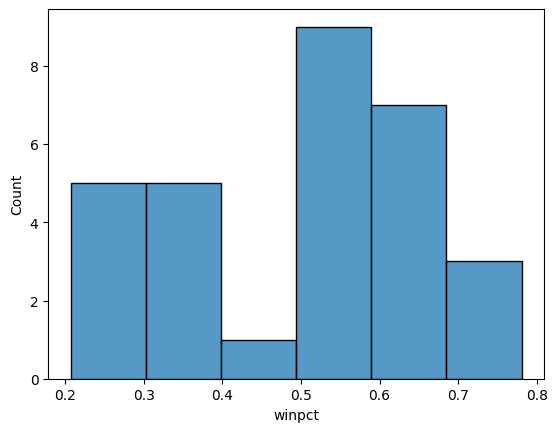

In [118]:
#Histograms of whole league
sns.histplot(standings['winpct'])

<Axes: xlabel='OFF_RATING', ylabel='Count'>

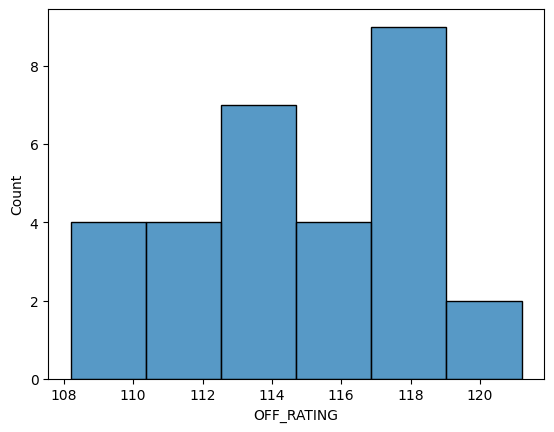

In [119]:
sns.histplot(standings['OFF_RATING'])

<Axes: xlabel='DEF_RATING', ylabel='Count'>

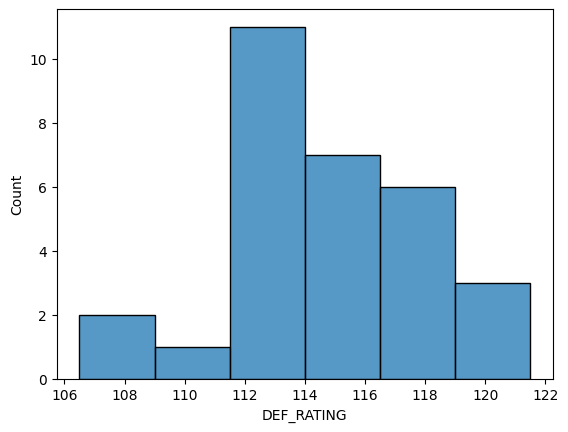

In [120]:
sns.histplot(standings['DEF_RATING'])

In [135]:
# Quick fix - convert categorical to string in the function
def plot_metric_by_stars(df, metric, metric_label, star_ratings, colors):
    # Create a temporary string version
    df_temp = df.copy()
    df_temp['NumStars_str'] = df_temp['NumStars'].astype(str)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'{metric_label} Distribution by Star Rating', fontsize=14)
    
    axes_flat = axes.flatten()
    
    # All data
    all_data = df_temp[metric].dropna()
    if len(all_data) > 0:
        axes_flat[0].hist(all_data, bins=8, alpha=0.7, color='gray', 
                          edgecolor='black', linewidth=0.8)
        axes_flat[0].axvline(all_data.mean(), color='red', linestyle='dashed', 
                             linewidth=2, label=f'Mean: {all_data.mean():.3f}')
        axes_flat[0].set_title(f'All Data (n={len(all_data)})', fontsize=12)
        axes_flat[0].set_xlabel(metric_label, fontsize=10)
        axes_flat[0].set_ylabel('Frequency', fontsize=10)
        axes_flat[0].legend()
        axes_flat[0].grid(True, alpha=0.3)
        # Store the x-limits from the full dataset
        x_min, x_max = axes_flat[0].get_xlim()
    
    groups = [0, 1, '2+']
    
    for idx, stars in enumerate(groups):
        plot_idx = idx + 1
        
        if stars == '2+':
            mask = df_temp['NumStars_str'].isin(['2', '3', '2+'])
        else:
            mask = df_temp['NumStars_str'] == str(stars)
        
        subset = df_temp[mask][metric].dropna()
        
        if len(subset) > 0:
            axes_flat[plot_idx].hist(subset, bins=8, alpha=0.7, 
                                     color=colors[idx], 
                                     edgecolor='black', linewidth=0.8)
            axes_flat[plot_idx].axvline(subset.mean(), color='red', 
                                        linestyle='dashed', linewidth=2, 
                                        label=f'Mean: {subset.mean():.3f}')
            axes_flat[plot_idx].set_title(f'{stars} Stars (n={len(subset)})', 
                                          fontsize=12)
            axes_flat[plot_idx].set_xlabel(metric_label, fontsize=10)
            axes_flat[plot_idx].set_ylabel('Frequency', fontsize=10)
            axes_flat[plot_idx].legend()
            axes_flat[plot_idx].grid(True, alpha=0.3)
            # Apply the same x-limits as the full dataset
            axes_flat[plot_idx].set_xlim(x_min, x_max)
        else:
            axes_flat[plot_idx].text(0.5, 0.5, f'No data for {stars} stars', 
                                     ha='center', va='center')
            axes_flat[plot_idx].set_title(f'{stars} Stars')
    
    plt.tight_layout()
    return fig

In [136]:
df_clean = standings.dropna(subset=['winpct', 'OFF_RATING', 'DEF_RATING', 'NumStars'])
star_ratings = [0, 1, '2+']
colors = ['blue', 'green', 'orange'][:len(star_ratings)]

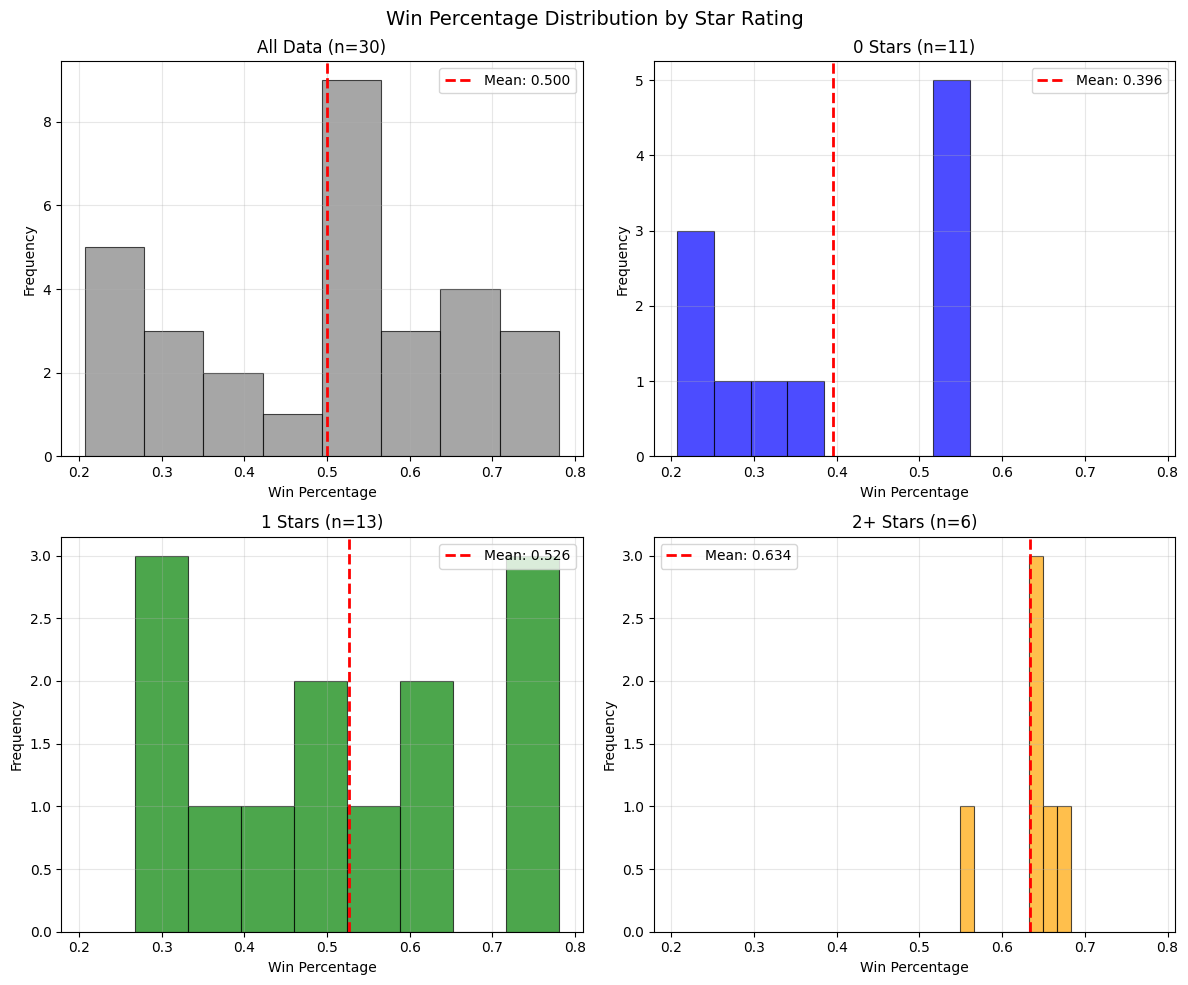

In [149]:
fig1 = plot_metric_by_stars(standings, 'winpct', 'Win Percentage', star_ratings, colors)
fig1.savefig('WinpctHists.png', dpi=300, bbox_inches='tight')
plt.show()


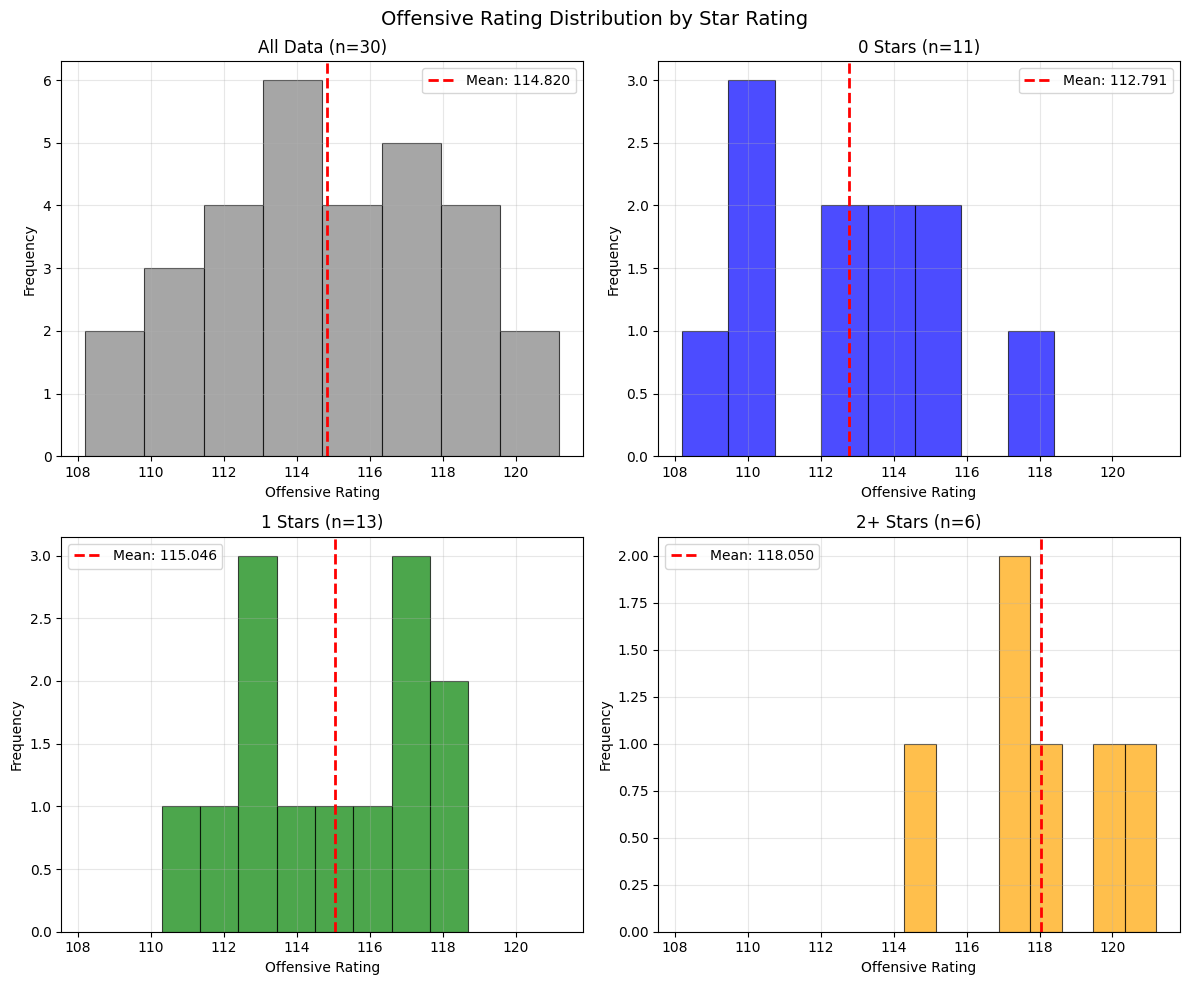

In [148]:
fig2 = plot_metric_by_stars(df_clean, 'OFF_RATING', 'Offensive Rating', star_ratings, colors)
fig2.savefig('OffRatHists.png', dpi=300, bbox_inches='tight')
plt.show()

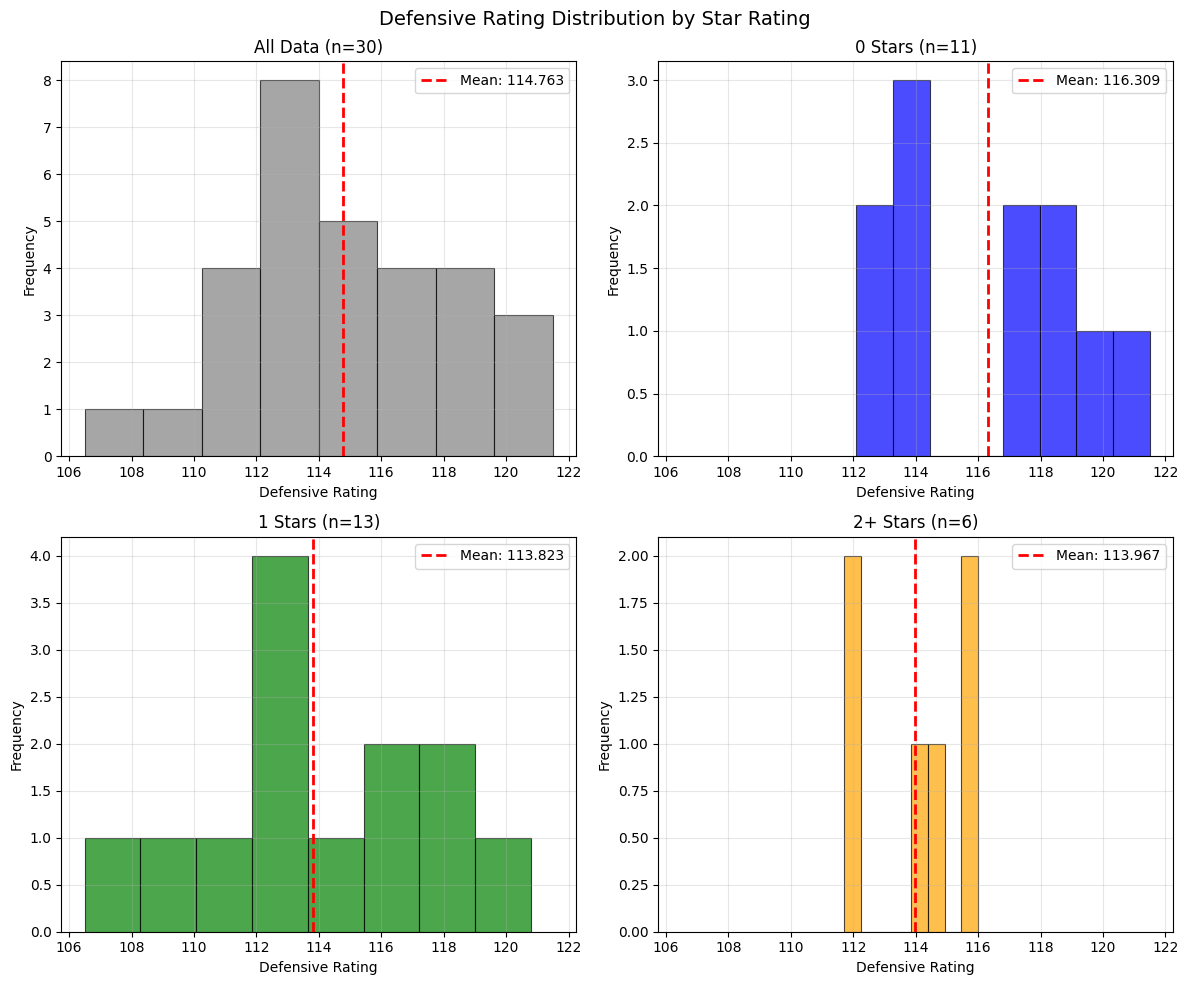

In [147]:
fig3 = plot_metric_by_stars(df_clean, 'DEF_RATING', 'Defensive Rating', star_ratings, colors)
fig3.savefig('DefRatHists.png', dpi=300, bbox_inches='tight')
plt.show()


In [150]:
standings['NumStars_numeric'] = standings['NumStars'].replace({'0': 0, '1': 1, '2+': 2})

# Calculate correlations
corr_win = standings['winpct'].corr(standings['NumStars_numeric'])
corr_off = standings['OFF_RATING'].corr(standings['NumStars_numeric'])
corr_def = standings['DEF_RATING'].corr(standings['NumStars_numeric'])

print(f"Correlation (Stars vs Win%): {corr_win:.3f}")
print(f"Correlation (Stars vs OFF_RATING): {corr_off:.3f}")
print(f"Correlation (Stars vs DEF_RATING): {corr_def:.3f}")

Correlation (Stars vs Win%): 0.534
Correlation (Stars vs OFF_RATING): 0.581
Correlation (Stars vs DEF_RATING): -0.290


C:\Users\danie\AppData\Local\Temp\ipykernel_23532\3910911067.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  standings['NumStars_numeric'] = standings['NumStars'].replace({'0': 0, '1': 1, '2+': 2})
C:\Users\danie\AppData\Local\Temp\ipykernel_23532\3910911067.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  standings['NumStars_numeric'] = standings['NumStars'].replace({'0': 0, '1': 1, '2+': 2})


In [151]:
# Run this and paste the output
print("=== DESCRIPTIVE STATISTICS ===\n")

print("Win Percentage:")
print(standings.groupby('NumStars')['winpct'].agg(['mean', 'std', 'count']))
print("\n")

print("Offensive Rating:")
print(standings.groupby('NumStars')['OFF_RATING'].agg(['mean', 'std', 'count']))
print("\n")

print("Defensive Rating:")
print(standings.groupby('NumStars')['DEF_RATING'].agg(['mean', 'std', 'count']))

=== DESCRIPTIVE STATISTICS ===

Win Percentage:
              mean       std  count
NumStars                           
0         0.395787  0.148597     11
1         0.526266  0.172956     13
2+        0.634146  0.045630      6


Offensive Rating:
                mean       std  count
NumStars                             
0         112.790909  3.044160     11
1         115.046154  2.711277     13
2+        118.050000  2.418884      6


Defensive Rating:
                mean       std  count
NumStars                             
0         116.309091  3.262654     11
1         113.823077  3.936190     13
2+        113.966667  1.750048      6


C:\Users\danie\AppData\Local\Temp\ipykernel_23532\2191023745.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(standings.groupby('NumStars')['winpct'].agg(['mean', 'std', 'count']))
C:\Users\danie\AppData\Local\Temp\ipykernel_23532\2191023745.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(standings.groupby('NumStars')['OFF_RATING'].agg(['mean', 'std', 'count']))
C:\Users\danie\AppData\Local\Temp\ipykernel_23532\2191023745.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior